In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, ttest_rel
%matplotlib inline

# ── Hyperparameters / config ──────────────────────────────────────────────
RAW_DATA = "raw_data.csv"  # relative to the notebook's own directory
ALPHA = 0.05  # significance level used by every test in this notebook

STRATEGY_STYLE = {
    "DelayExclusion":  {"color": "steelblue"},
    "RandomExclusion": {"color": "crimson"},
    "NoExclusion":     {"color": "green"},
    "SEER":            {"color": "purple"},
}
TICKS_PCT   = np.arange(0, 1.001, 0.25)
TICK_LABELS = [f"{int(t*100)}%" for t in TICKS_PCT]

MERGE_KEYS = ["Instance", "Number of agents", "Number of goals"]
LEVEL_ORDER = ["1", "20%", "40%", "60%", "80%", "N-1"]

# SST cactus plot: DelayExclusion / RandomExclusion at these removal levels
EXCL_LEVELS_FOR_PLOT = ["20%", "40%"]
# Distinct dash patterns per line (not just color) so lines stay distinguishable in grayscale print
CACTUS_LINESTYLE = {
    "NoExclusion": "-",
    "SEER": (0, (5, 5)),
    ("DelayExclusion", "20%"): (0, (1, 1)),
    ("DelayExclusion", "40%"): (0, (3, 5, 1, 5)),
    ("RandomExclusion", "20%"): (0, (5, 1)),
    ("RandomExclusion", "40%"): (0, (3, 1, 1, 1)),
}

# ── Helpers ──────────────────────────────────────────────────────────────
def sig_mark(p):
    """Format a p-value with a two-tailed significance tick at ALPHA."""
    return "—" if pd.isna(p) else f"{p:.2e} {'✓' if p < ALPHA else '✗'}"


def _nice_axis(global_max, n_ticks=5):
    """Return (y_max, yticks) with ~n_ticks intervals and 5% headroom above global_max."""
    padded = global_max * 1.05
    raw_step = padded / n_ticks
    magnitude = 10 ** math.floor(math.log10(raw_step))
    step = int(10 * magnitude)
    for factor in [1, 2, 3, 5, 10]:
        candidate = int(factor * magnitude)
        if candidate * n_ticks >= padded:
            step = candidate
            break
    y_max = int(math.ceil(padded / step)) * step
    return y_max, list(range(0, y_max + 1, step))


def grid_axes(dmap):
    """First 3 agent counts × first 3 goal counts, plus the per-cell subframes."""
    agent_vals = sorted(dmap["Number of agents"].unique())[:3]
    goal_vals  = sorted(dmap["Number of goals"].unique())[:3]
    subs = {
        (r, c): dmap[(dmap["Number of agents"] == a) & (dmap["Number of goals"] == g)]
        for r, a in enumerate(agent_vals)
        for c, g in enumerate(goal_vals)
    }
    return agent_vals, goal_vals, subs


def _removal_level(row):
    n, r = row["Number of agents"], row["Number of removed agents"]
    if r == 1: return "1"
    if r == n - 1: return "N-1"
    return f"{int(round(r / n * 100))}%"


def agg_context(dmap):
    """Per-map data slices needed for the SST cactus plot."""
    wr_df = dmap[dmap["How To Remove"] == "NoExclusion"][MERGE_KEYS + ["Online SST", "Runtime"]]
    sm_df = dmap[dmap["How To Remove"] == "SEER"][MERGE_KEYS + ["Online SST", "Runtime"]]

    excl_full = dmap[dmap["How To Remove"].isin(["DelayExclusion", "RandomExclusion"])].copy()
    excl_full["removal_level"] = excl_full.apply(_removal_level, axis=1)
    excl_by_strategy_lvl = {
        (s, lvl): excl_full[(excl_full["How To Remove"] == s) & (excl_full["removal_level"] == lvl)][MERGE_KEYS + ["Online SST", "Runtime"]]
        for s in ["DelayExclusion", "RandomExclusion"]
        for lvl in EXCL_LEVELS_FOR_PLOT
    }

    return {"wr_df": wr_df, "sm_df": sm_df, "excl_by_strategy_lvl": excl_by_strategy_lvl}


# ── Load merged data, list maps, build per-map aggregate context ──────────
df_all = pd.read_csv(RAW_DATA)
df_all["success"] = df_all["Online SST"].notna()
maps = sorted(df_all["Map"].unique())

ctx_by_map = {m: agg_context(df_all[df_all["Map"] == m]) for m in maps}

## SEER Pre-Planning Overhead

In [2]:
# SEER Choose Remove Time at the largest (agents, goals) config per map
rows = []
for m in maps:
    d = df_all[(df_all["Map"] == m) & (df_all["How To Remove"] == "SEER")]
    if d.empty:
        continue
    ma, mg = d["Number of agents"].max(), d["Number of goals"].max()
    t = d[(d["Number of agents"] == ma) & (d["Number of goals"] == mg)]["Choose Remove Time"].dropna()
    if t.empty:
        continue
    rows.append({"Map": m, "Num Agents": int(ma), "Num Goals": int(mg),
                 "Avg Choose Remove Time (s)": round(t.mean(), 3)})
choose_remove_time = pd.DataFrame(rows)
choose_remove_time

,Map,Num Agents,Num Goals,Avg Choose Remove Time (s)
0,den520d,150,300,12.677
1,ht_chantry,150,300,4.629
2,lak303d,150,300,7.384
3,maze-32-32-2,40,150,0.205
4,random-32-32-20,40,150,0.217
5,room-32-32-4,40,150,0.208


## SEER versus Retaining All Agents

In [3]:
# SEER vs NoExclusion across all maps, with two-tailed significance tests (alpha=0.05)
#   Solved %        -> McNemar exact (paired binary), two-sided
#   Avg Online SST  -> paired t-test (ttest_rel), two-sided, on co-solved instances
#   Avg Runtime     -> paired t-test (ttest_rel), two-sided, on co-solved instances
rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    ad = dm[dm["How To Remove"] == "SEER"][MERGE_KEYS + ["success", "Online SST", "Runtime"]]
    nd = dm[dm["How To Remove"] == "NoExclusion"][MERGE_KEYS + ["success", "Online SST", "Runtime"]]
    mg = ad.merge(nd, on=MERGE_KEYS, suffixes=("_a", "_n"))

    # Solved % (paired) + McNemar two-sided
    b = int((mg["success_a"] & ~mg["success_n"]).sum())   # SEER solved, NoExclusion not
    c = int((~mg["success_a"] & mg["success_n"]).sum())   # NoExclusion solved, SEER not
    p_solved = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0

    # Co-solved set (both solved) + paired t-tests two-sided
    co = mg[mg["success_a"] & mg["success_n"]]
    co_pct = len(co) / len(mg) * 100 if len(mg) else 0
    p_sst = ttest_rel(co["Online SST_a"], co["Online SST_n"]).pvalue if len(co) > 1 else float("nan")
    p_rt  = ttest_rel(co["Runtime_a"],   co["Runtime_n"]).pvalue   if len(co) > 1 else float("nan")

    stats = {
        "SEER":       (mg["success_a"].mean() * 100, co["Runtime_a"].mean(), co["Online SST_a"].mean()),
        "NoExclusion": (mg["success_n"].mean() * 100, co["Runtime_n"].mean(), co["Online SST_n"].mean()),
    }
    for s, (solved, rt, sst) in stats.items():
        rows.append({
            "Map": m, "Strategy": s,
            "Solved %": f"{solved:.2f}%",
            "Co-solved %": f"{co_pct:.2f}%",
            "Avg Runtime": round(rt, 2),
            "Avg Online SST": round(sst, 2),
            "Solved p (McNemar)":  sig_mark(p_solved) if s == "SEER" else "",
            "SST p (t-test)":      sig_mark(p_sst)    if s == "SEER" else "",
            "Runtime p (t-test)":  sig_mark(p_rt)     if s == "SEER" else "",
        })
seer_vs_noexclusion = pd.DataFrame(rows)
seer_vs_noexclusion

,Map,Strategy,Solved %,Co-solved %,Avg Runtime,Avg Online SST,Solved p (McNemar),SST p (t-test),Runtime p (t-test)
0,den520d,SEER,92.58%,81.87%,86.89,15451.99,3.02e-21 ✓,0.00e+00 ✓,2.84e-14 ✓
1,den520d,NoExclusion,87.00%,81.87%,96.73,17430.33,,,
2,ht_chantry,SEER,77.20%,54.00%,105.22,7790.67,1.76e-45 ✓,3.18e-249 ✓,4.32e-22 ✓
3,ht_chantry,NoExclusion,64.98%,54.00%,123.07,8650.39,,,
4,lak303d,SEER,81.53%,62.44%,96.91,11767.75,3.25e-26 ✓,4.54e-303 ✓,1.68e-37 ✓
5,lak303d,NoExclusion,72.98%,62.44%,118.23,13109.39,,,
6,maze-32-32-2,SEER,67.89%,51.16%,61.80,3006.94,3.28e-22 ✓,5.44e-40 ✓,2.05e-10 ✓
7,maze-32-32-2,NoExclusion,60.53%,51.16%,72.24,3171.30,,,
8,random-32-32-20,SEER,83.16%,70.22%,57.42,2669.34,1.05e-15 ✓,5.30e-57 ✓,5.09e-19 ✓
9,random-32-32-20,NoExclusion,77.76%,70.22%,69.62,2814.35,,,


## Solved-Rate Gains across Instance Configurations

In [4]:
# Per-config solved-rate gain (SEER% − NoExclusion%) + McNemar paired test
# Sign: +N% = SEER solved N percentage points more, -N% = NoExclusion solved more
# McNemar (exact binomial on discordant pairs): b = SEER-only solved, c = NoExclusion-only solved
rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    for a in sorted(dm["Number of agents"].unique()):
        for g in sorted(dm["Number of goals"].unique()):
            mask = (dm["Number of agents"] == a) & (dm["Number of goals"] == g)
            a_df = dm[mask & (dm["How To Remove"] == "SEER")][["Instance", "success"]]
            n_df = dm[mask & (dm["How To Remove"] == "NoExclusion")][["Instance", "success"]]
            if a_df.empty or n_df.empty:
                continue
            merged = a_df.merge(n_df, on="Instance", suffixes=("_a", "_n"))
            gain = (merged["success_a"].mean() - merged["success_n"].mean()) * 100
            b = (merged["success_a"] & ~merged["success_n"]).sum()   # SEER solved, NoExclusion not
            c = (~merged["success_a"] & merged["success_n"]).sum()   # NoExclusion solved, SEER not
            pval = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0
            rows.append({"Map": m, "Agents": a, "Goals": g,
                         "Gain": f"{gain:+.1f}%",
                         "McNemar p": f"{pval:.4f}",
                         "Significant": "Yes" if pval < ALPHA else "No"})
config_gain = pd.DataFrame(rows)
config_gain

,Map,Agents,Goals,Gain,McNemar p,Significant
0,den520d,100,200,+4.8%,0.0005,Yes
1,den520d,100,250,+5.6%,0.0013,Yes
2,den520d,100,300,+6.0%,0.0042,Yes
3,den520d,120,200,+4.2%,0.0046,Yes
4,den520d,120,250,+8.2%,0.0000,Yes
5,den520d,120,300,+4.8%,0.0264,Yes
6,den520d,150,200,+3.8%,0.0066,Yes
7,den520d,150,250,+4.2%,0.0275,Yes
8,den520d,150,300,+8.6%,0.0001,Yes
9,ht_chantry,100,200,+10.4%,0.0000,Yes


## Online-SST Performance across Solved Instances

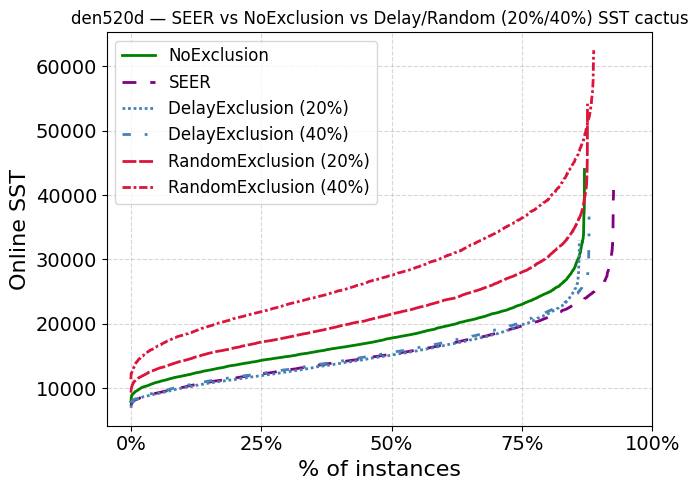

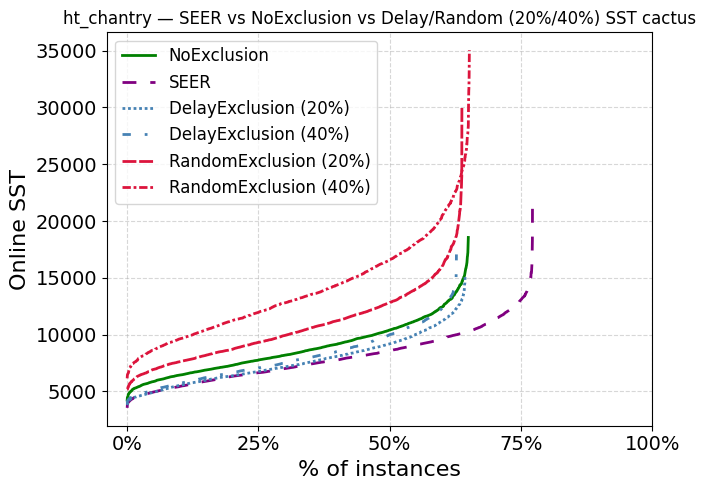

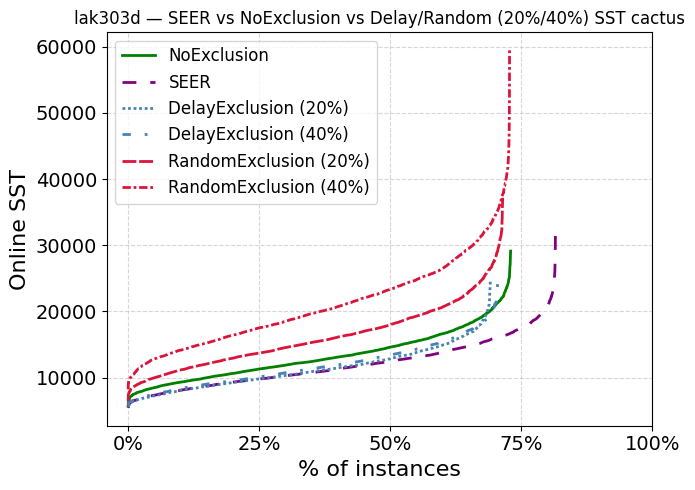

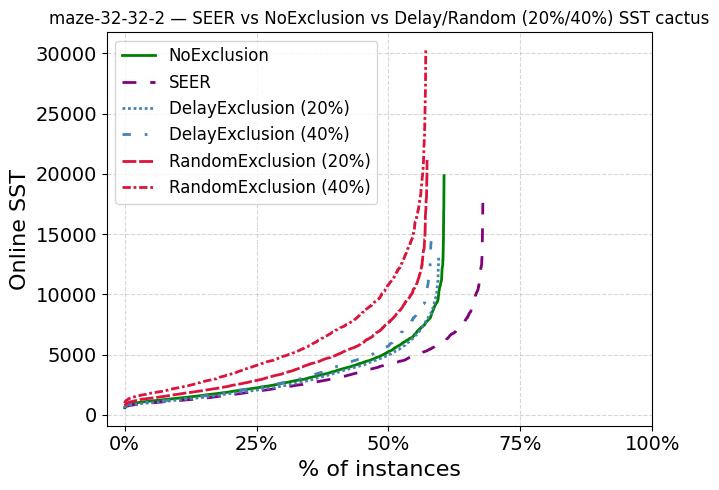

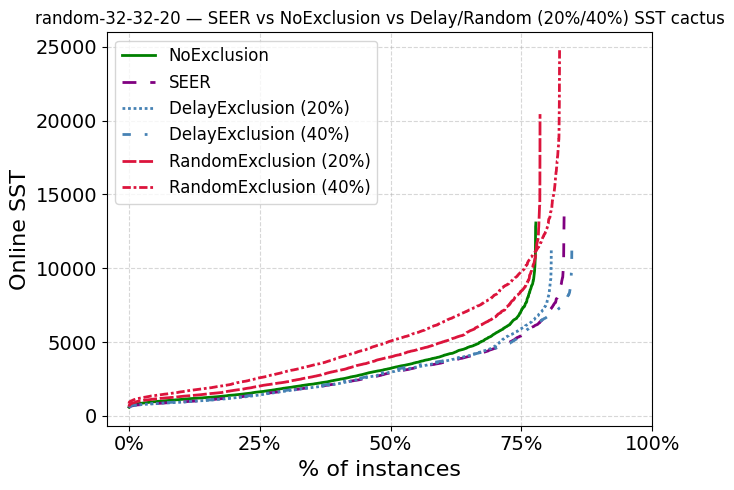

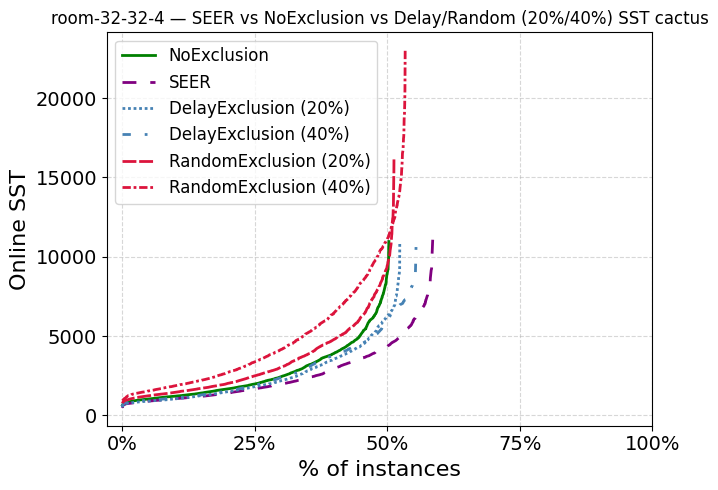

In [5]:
def plot_sst_cactus(ctx, map_name):
    fig, ax = plt.subplots(figsize=(7, 5))
    for strategy, src in (("NoExclusion", ctx["wr_df"]), ("SEER", ctx["sm_df"])):
        vals = src["Online SST"].dropna().sort_values().values
        n_total = len(src)
        if len(vals) == 0 or n_total == 0:
            continue
        ax.plot(np.arange(1, len(vals) + 1) / n_total, vals,
                label=strategy, color=STRATEGY_STYLE[strategy]["color"], linewidth=2,
                linestyle=CACTUS_LINESTYLE[strategy])

    for strategy in ("DelayExclusion", "RandomExclusion"):
        for lvl in EXCL_LEVELS_FOR_PLOT:
            src = ctx["excl_by_strategy_lvl"][(strategy, lvl)]
            vals = src["Online SST"].dropna().sort_values().values
            n_total = len(src)
            if len(vals) == 0 or n_total == 0:
                continue
            ax.plot(np.arange(1, len(vals) + 1) / n_total, vals,
                    label=f"{strategy} ({lvl})", color=STRATEGY_STYLE[strategy]["color"], linewidth=2,
                    linestyle=CACTUS_LINESTYLE[(strategy, lvl)])

    ax.set_xlabel("% of instances", fontsize=16)
    ax.set_ylabel("Online SST", fontsize=16)
    ax.set_xticks(TICKS_PCT)
    ax.set_xticklabels(TICK_LABELS, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(f"{map_name} — SEER vs NoExclusion vs Delay/Random (20%/40%) SST cactus", fontsize=12)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_sst_cactus(ctx_by_map[m], m)

## Adaptive Exclusion Behavior of SEER

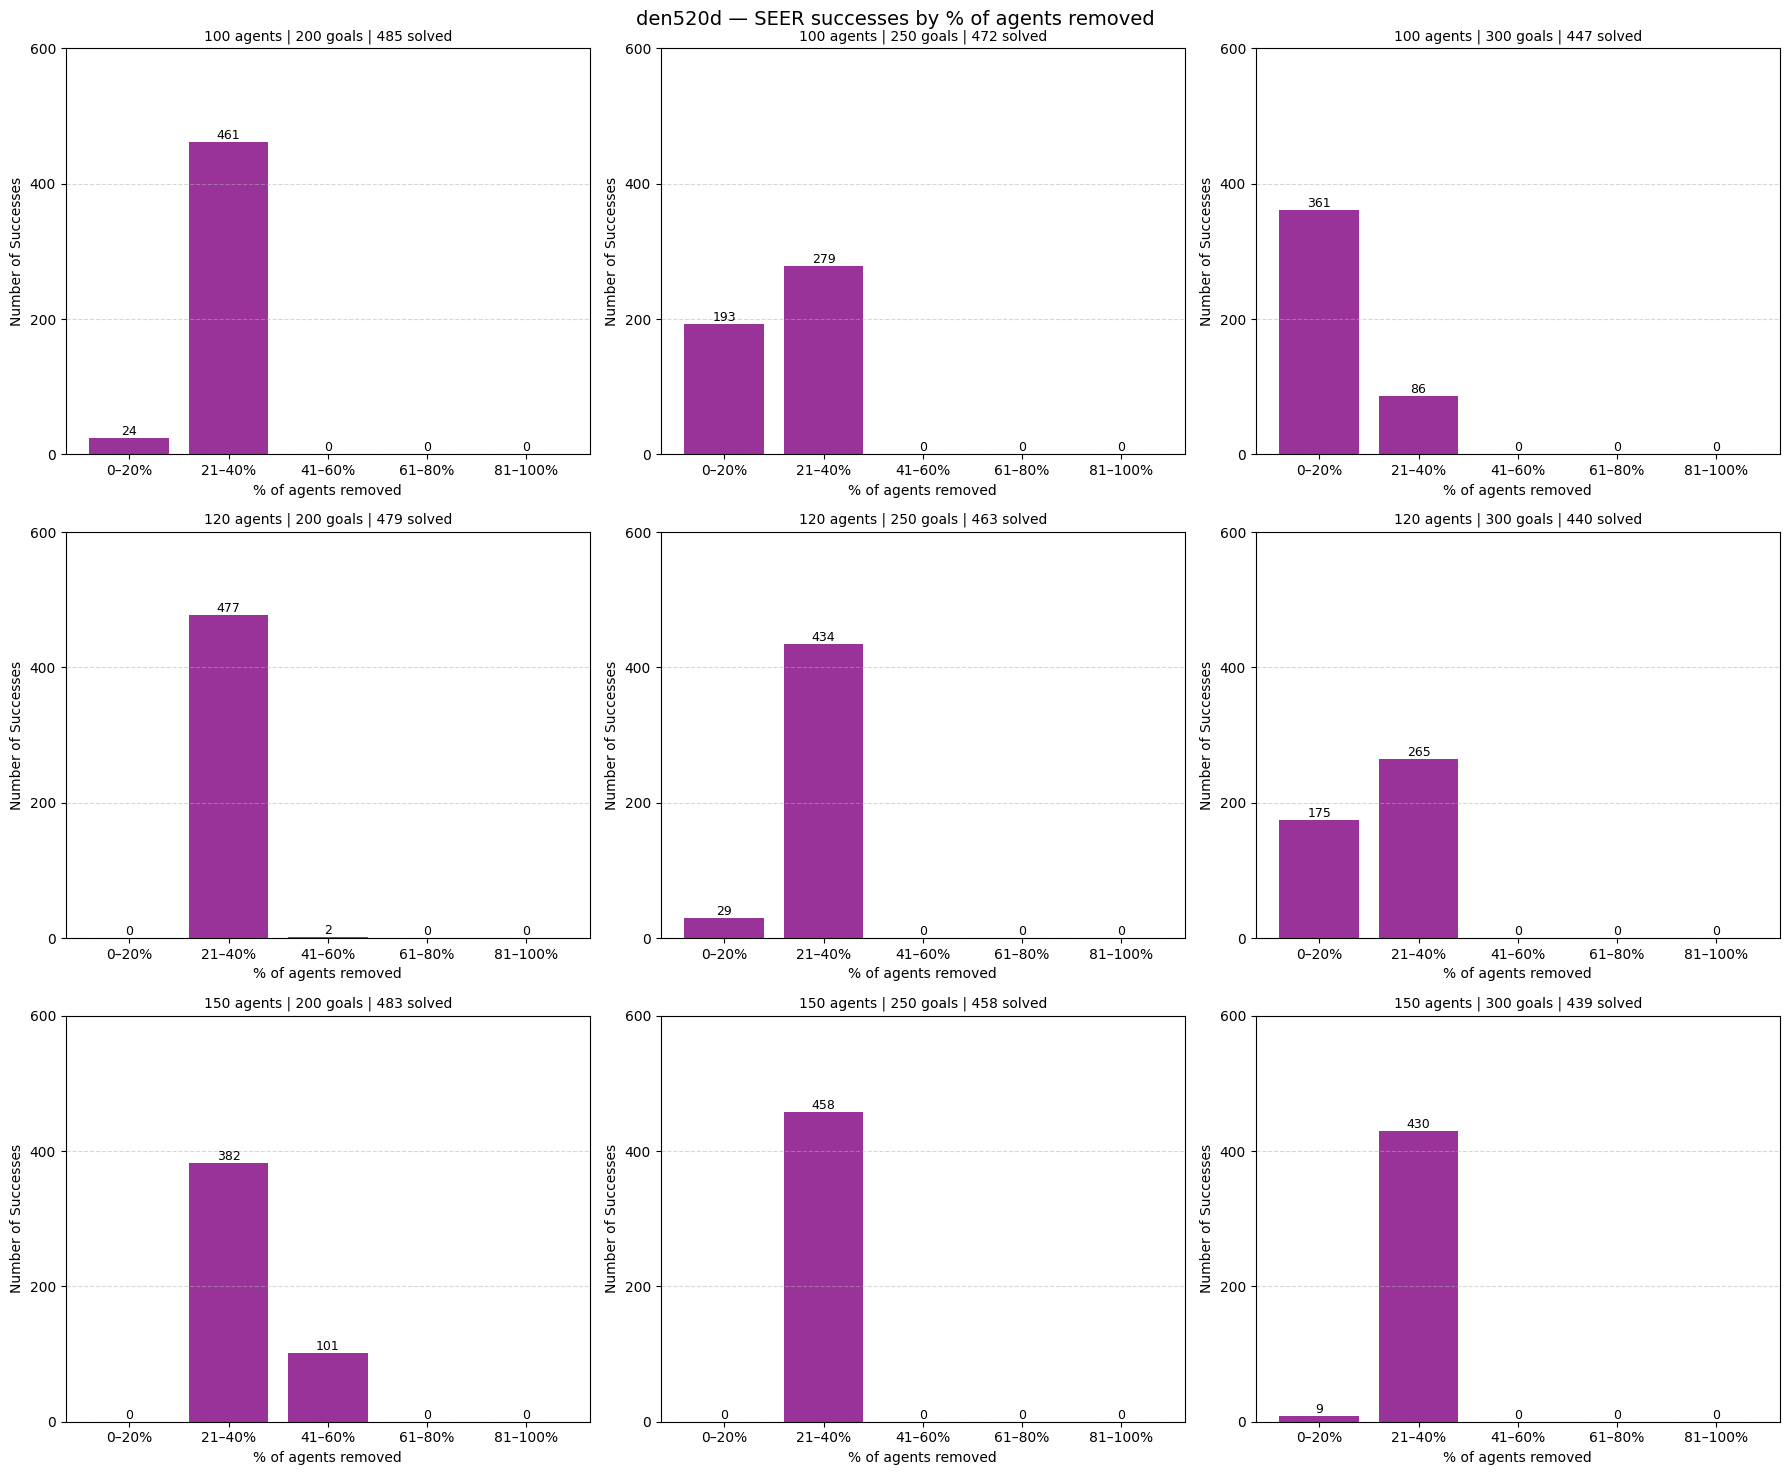

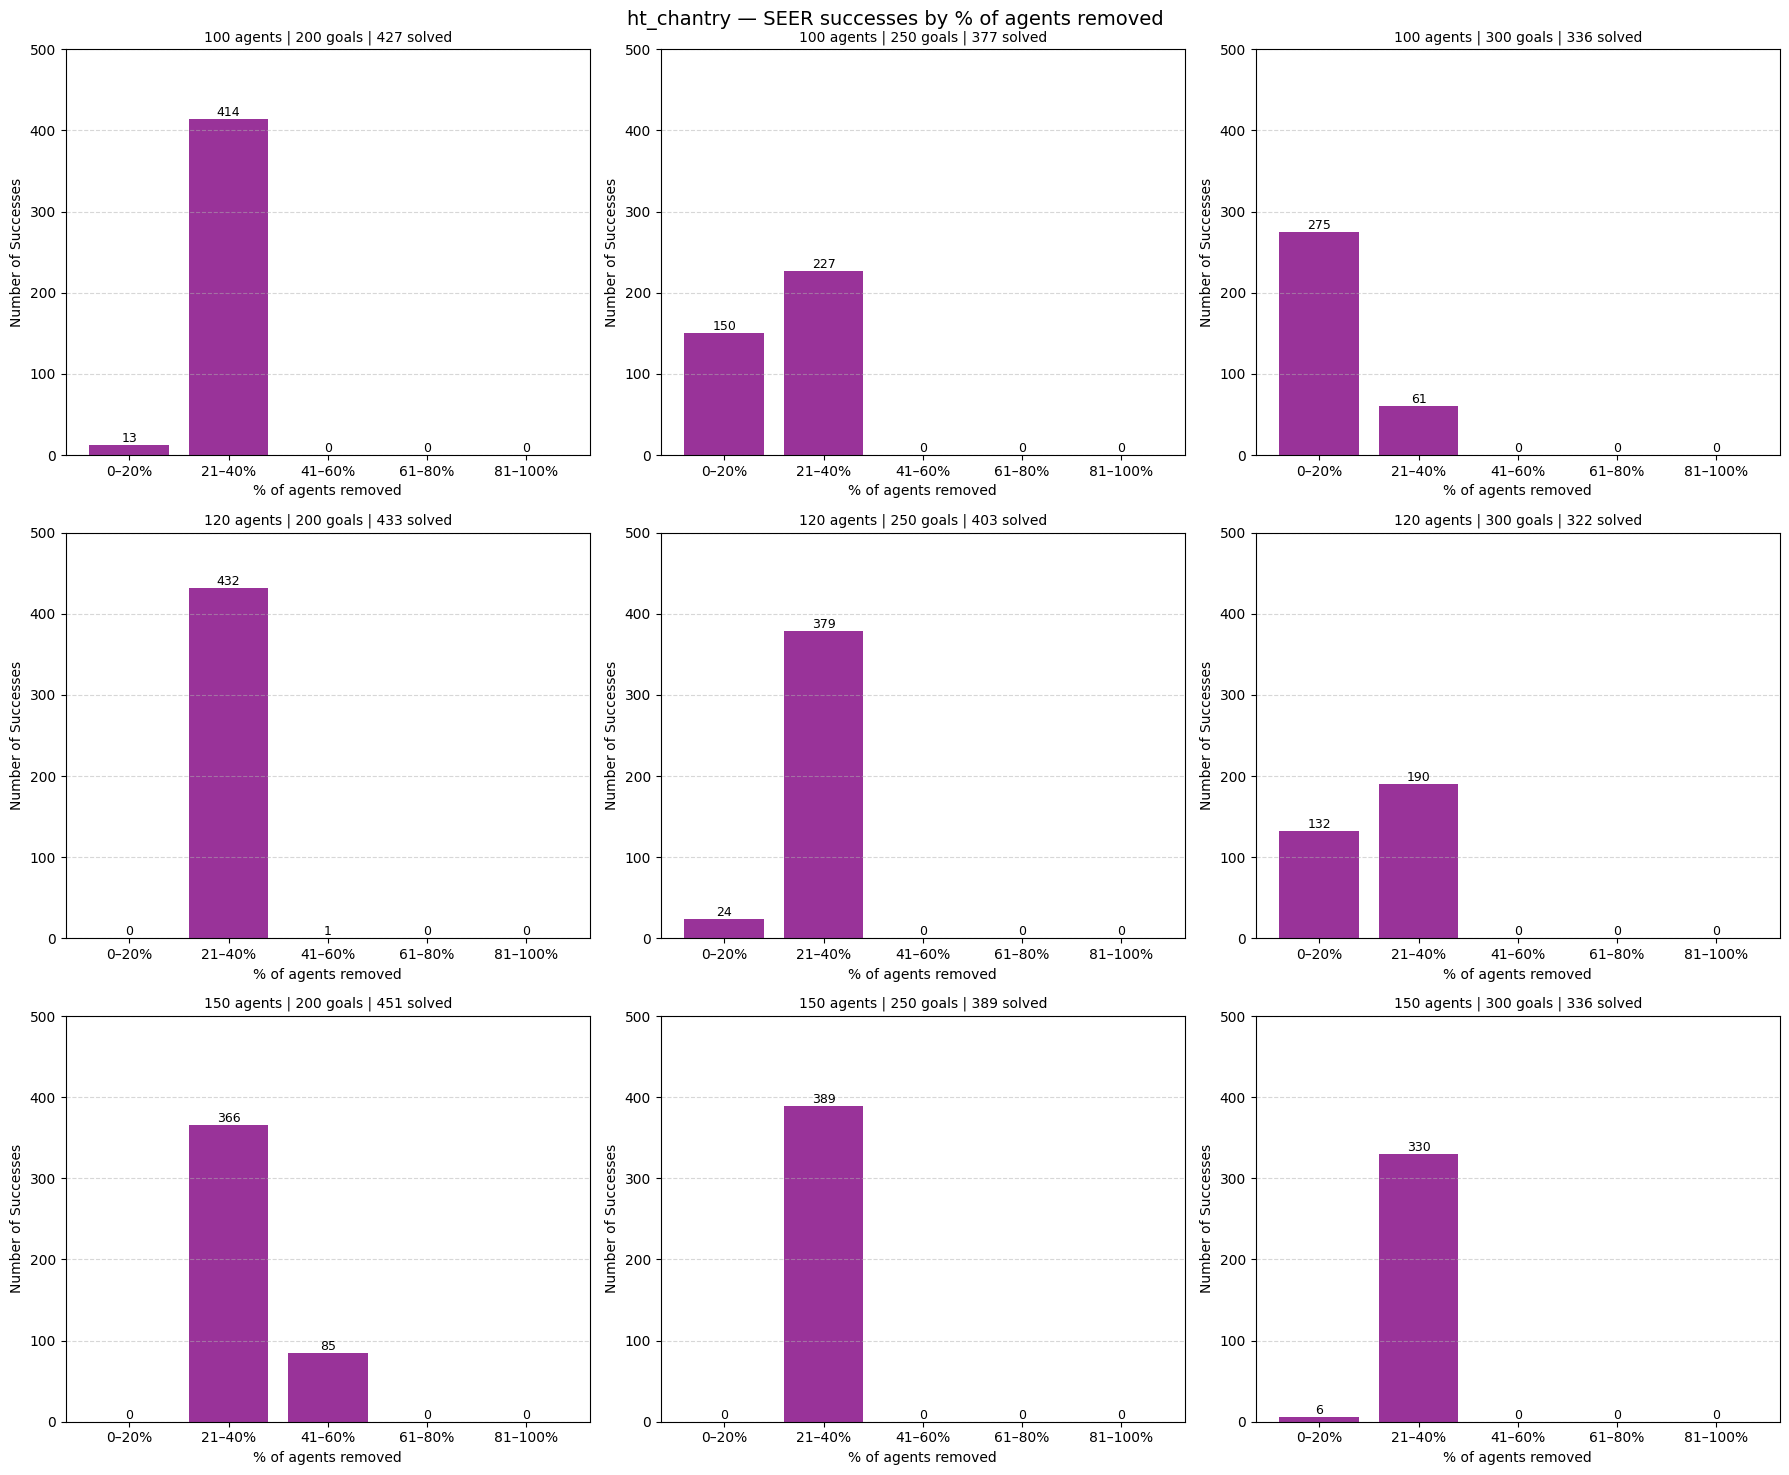

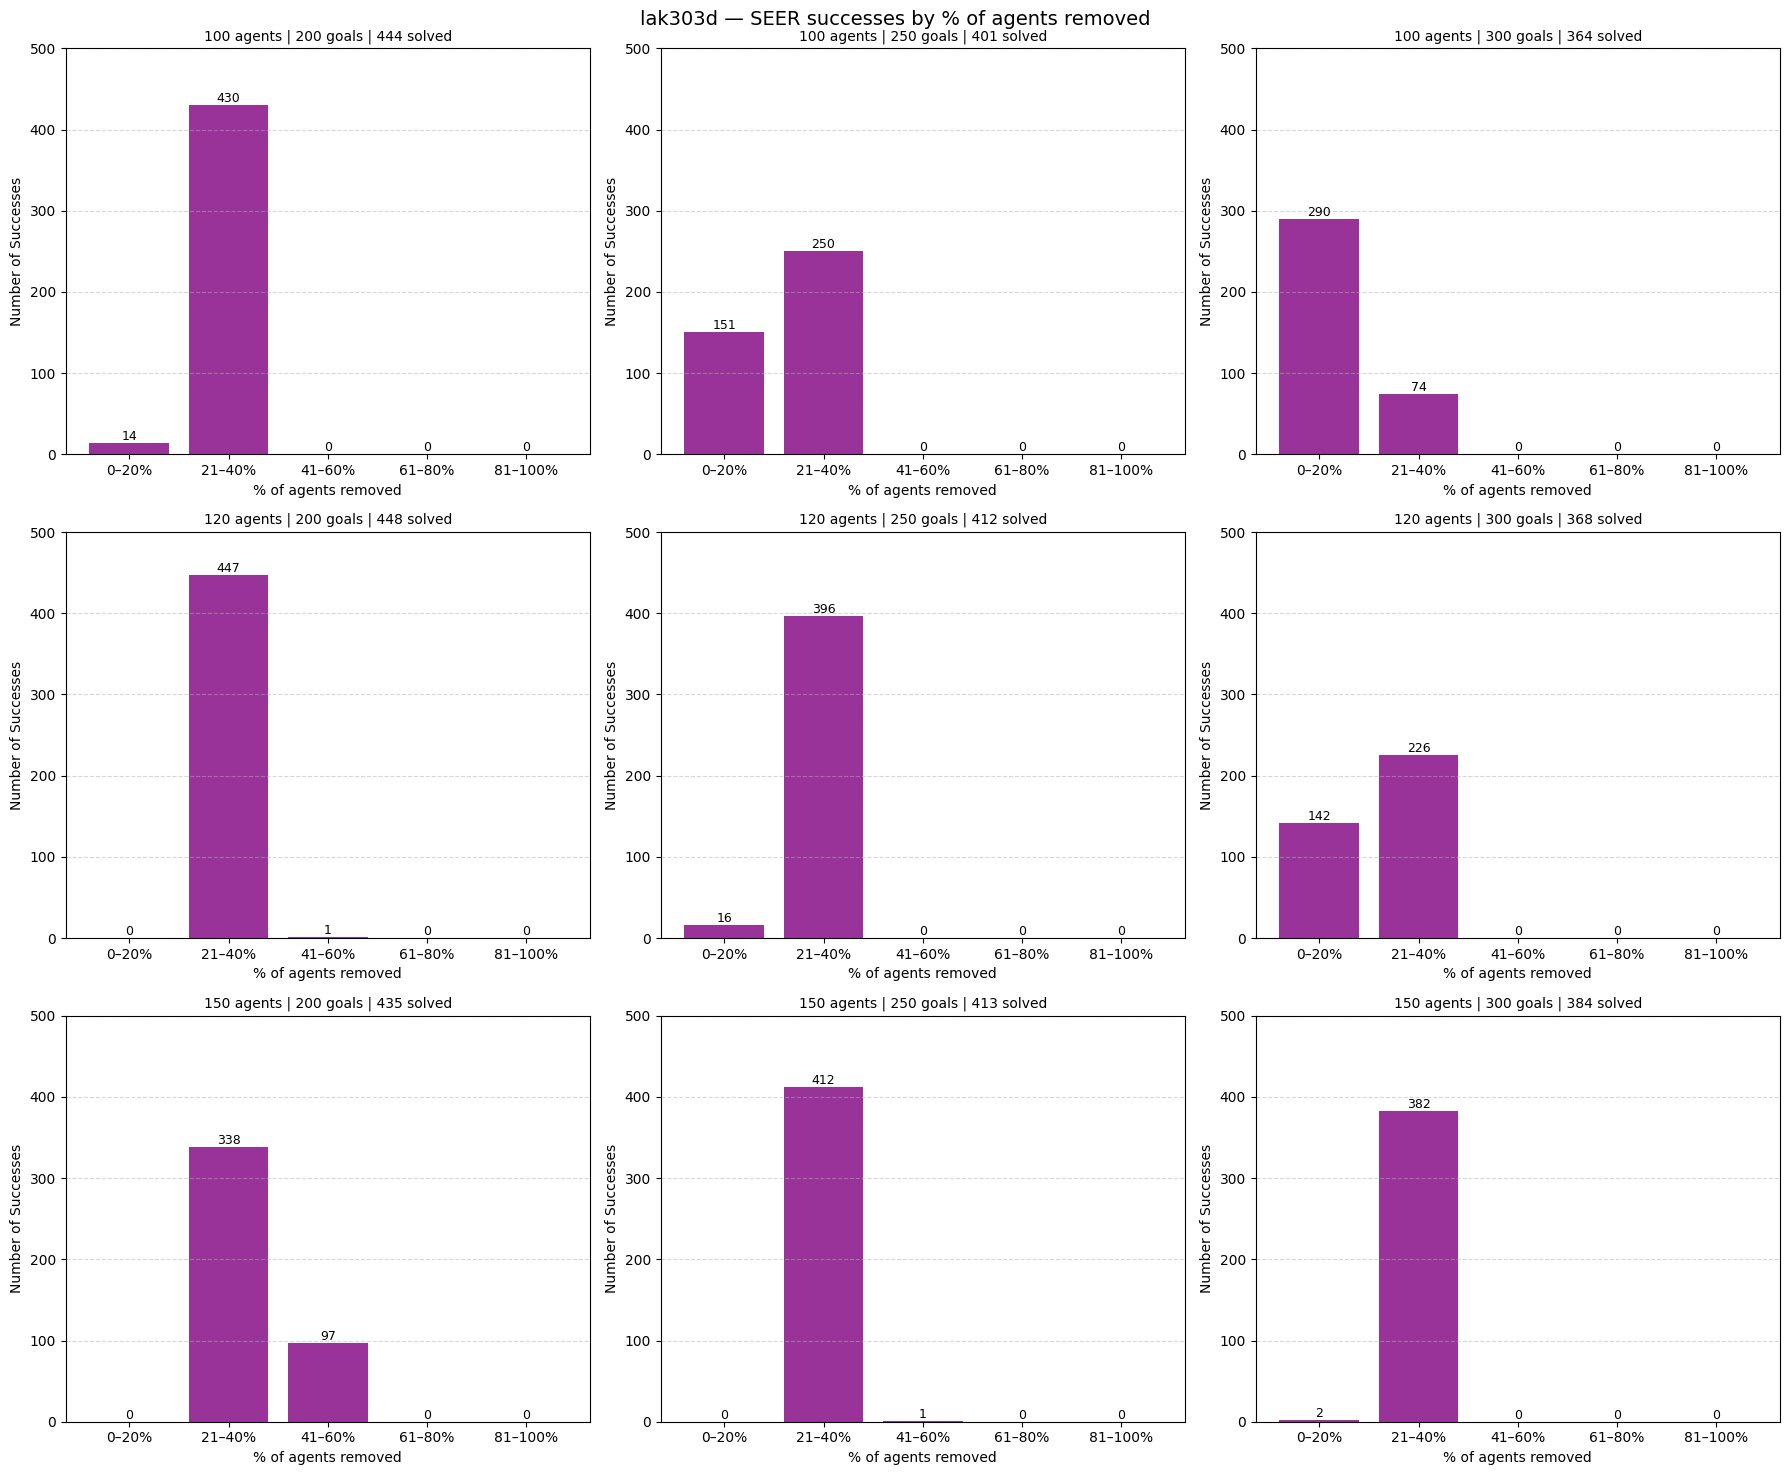

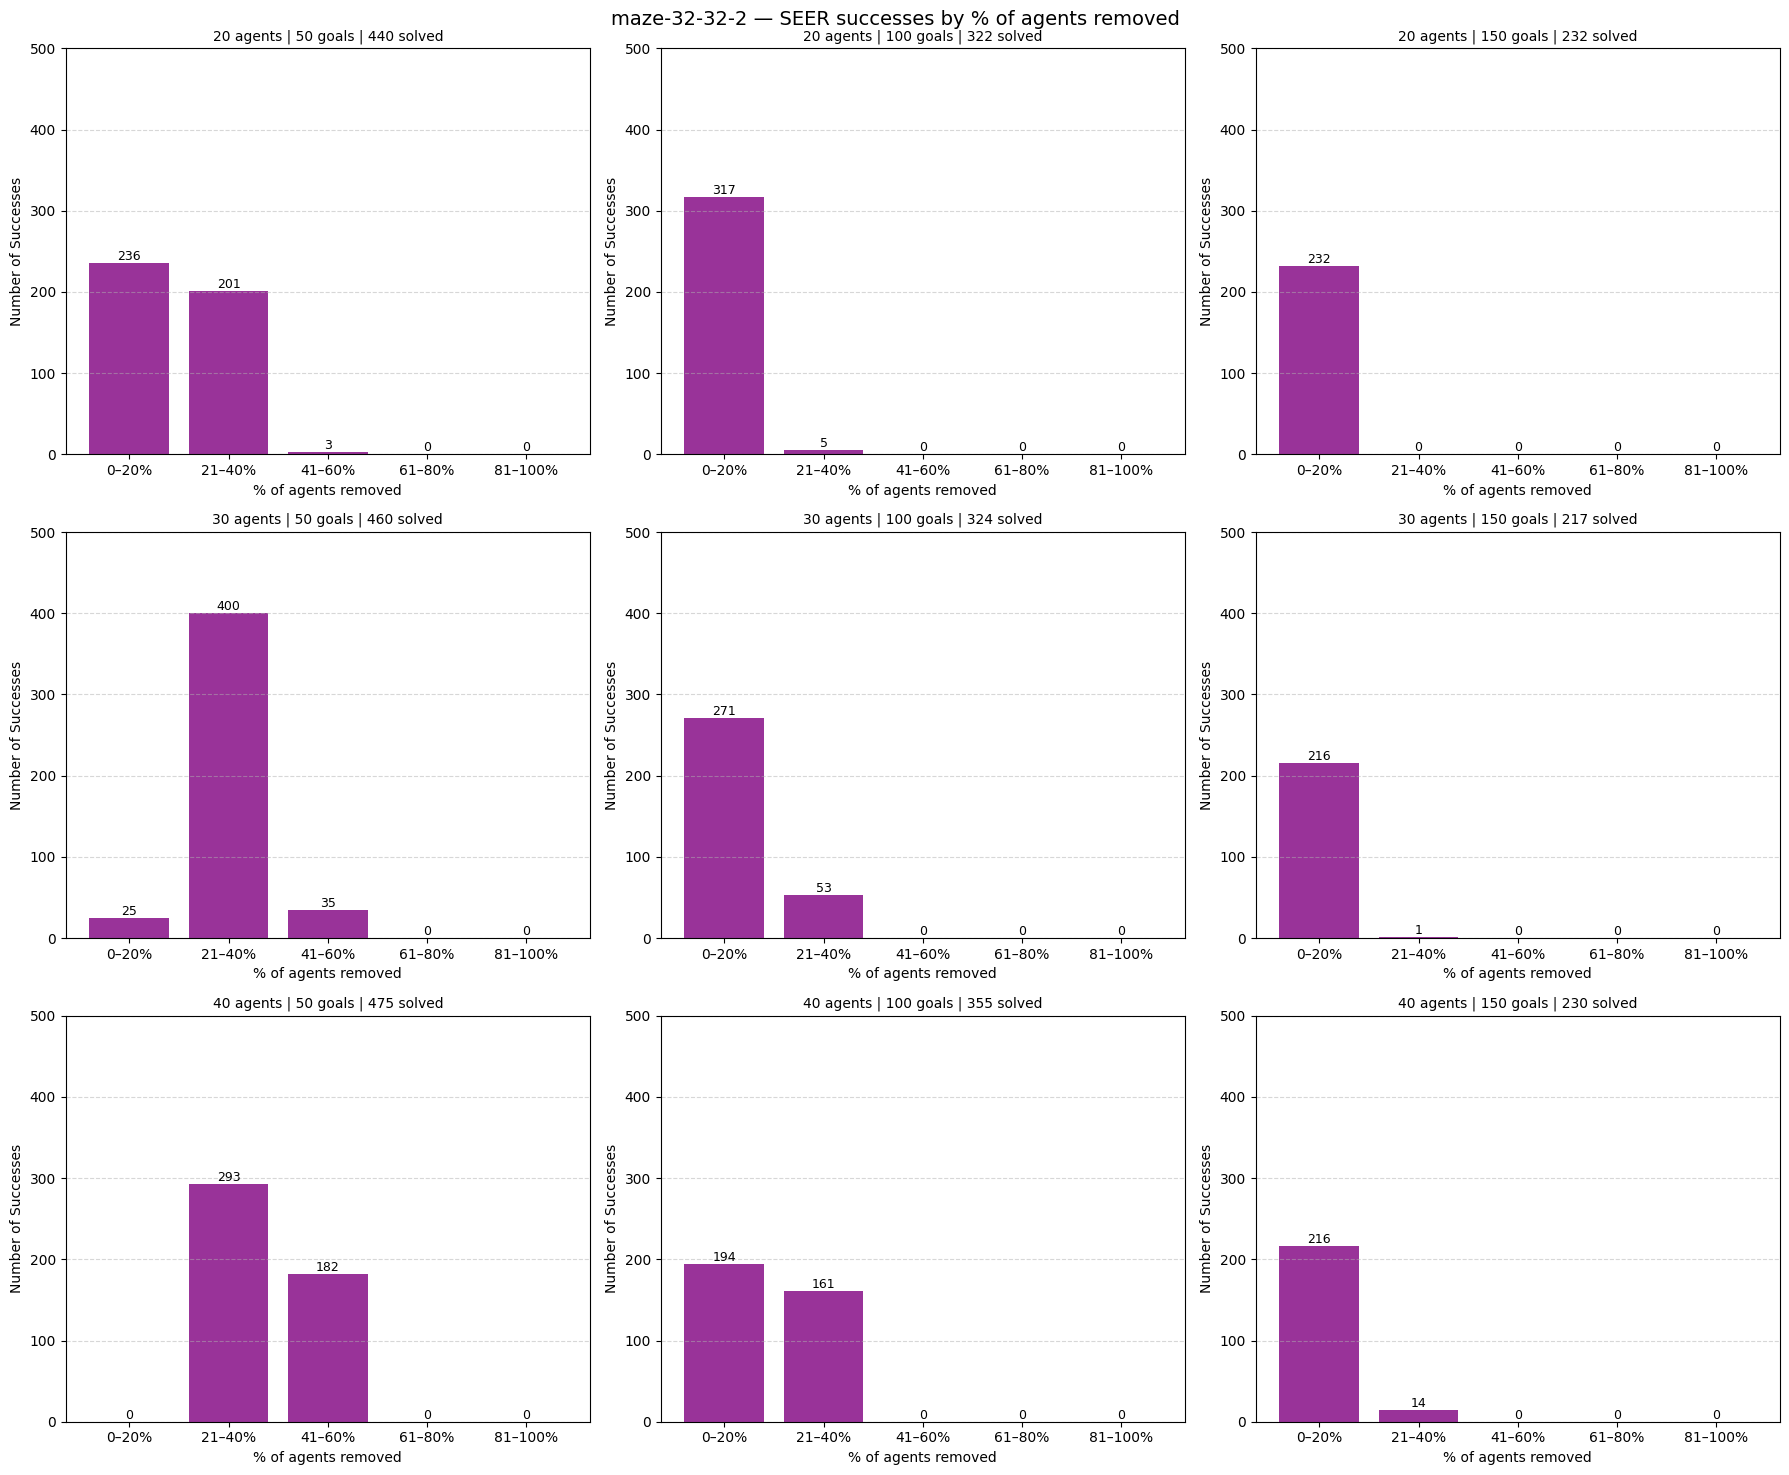

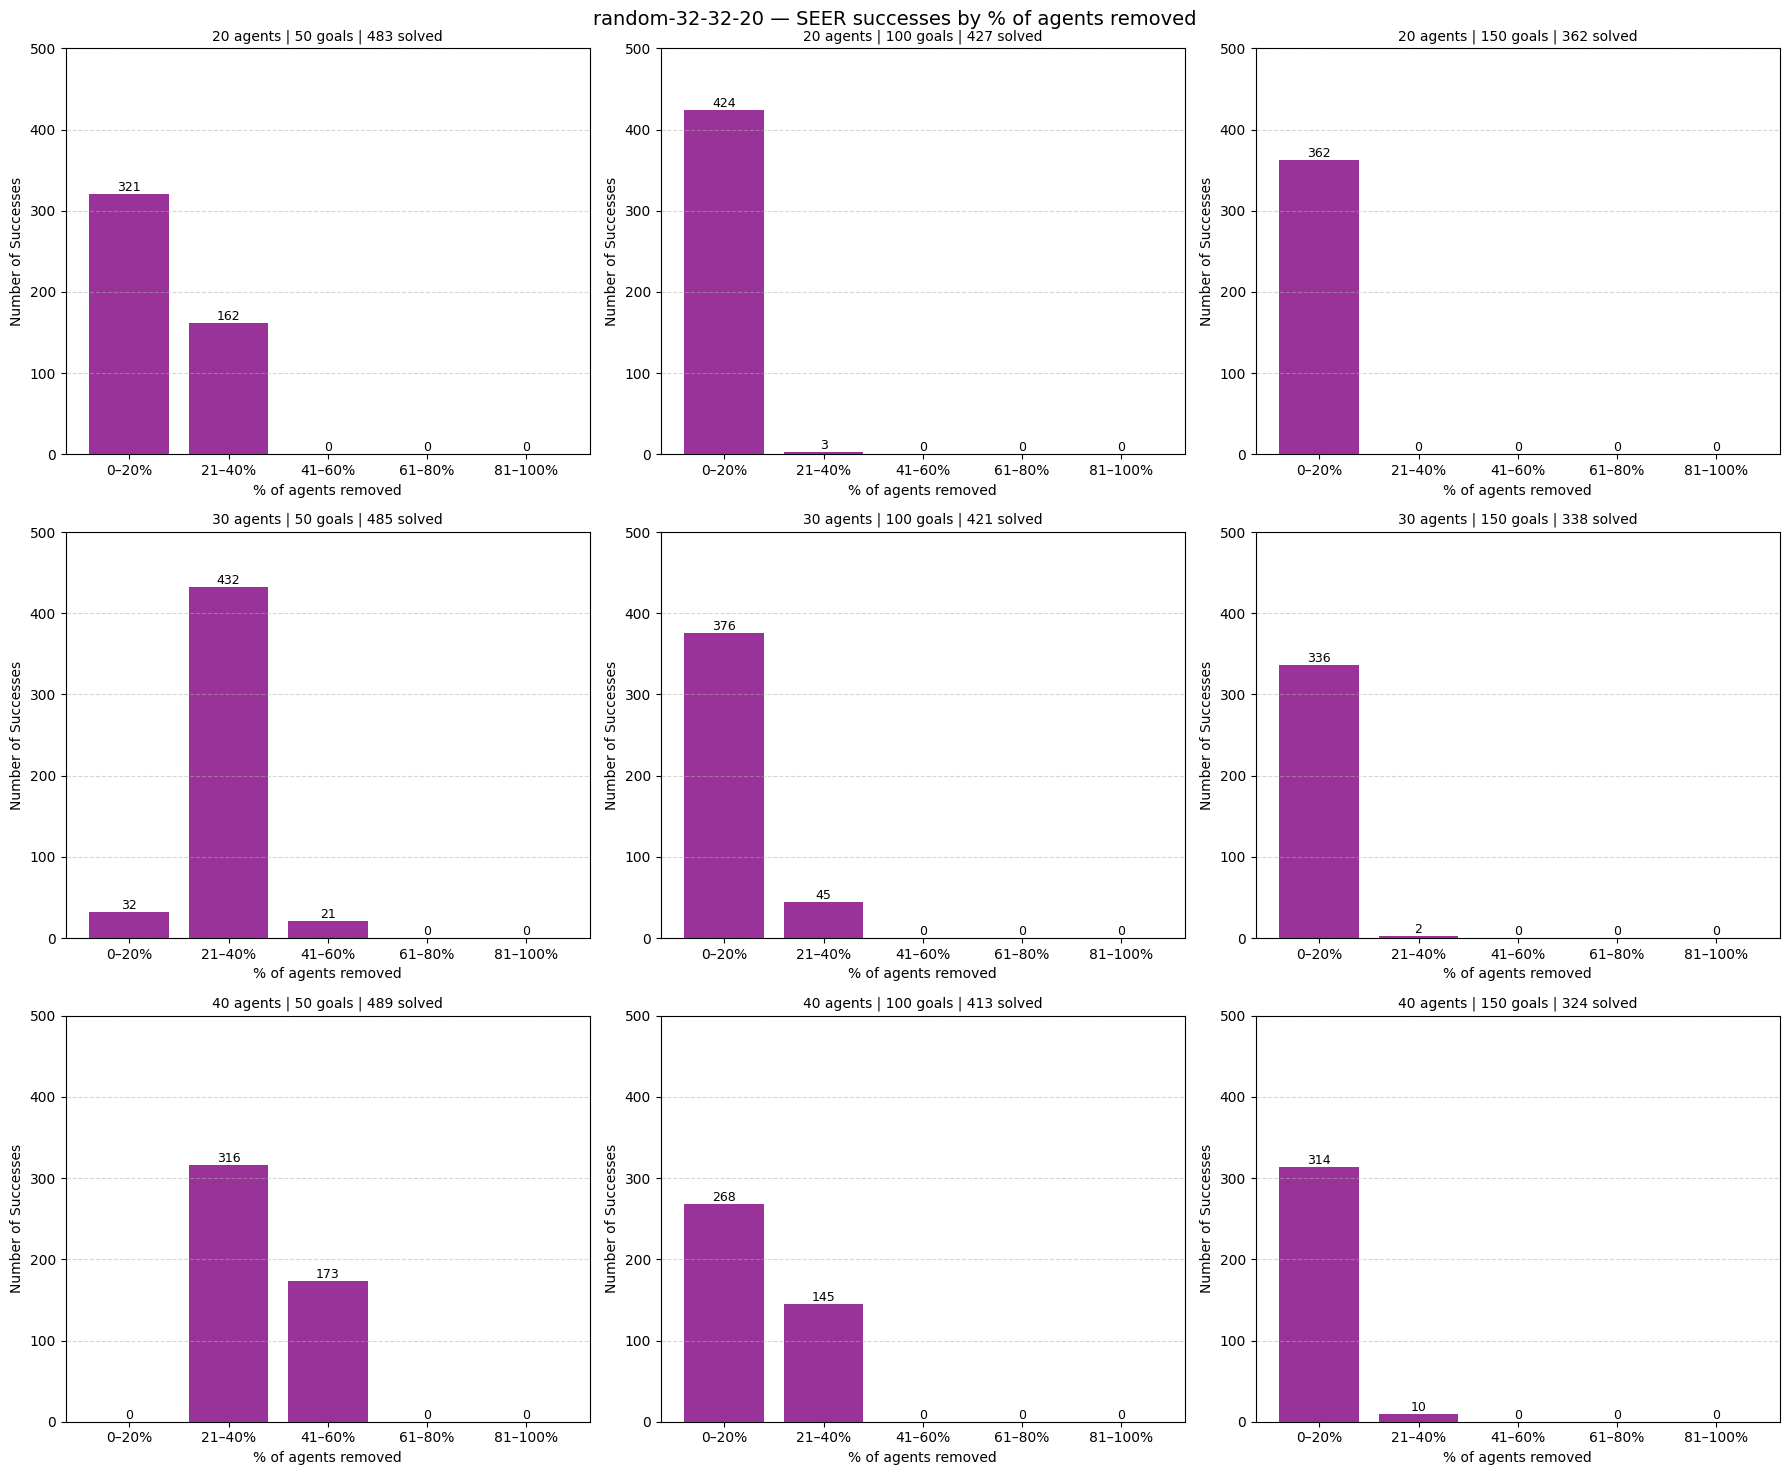

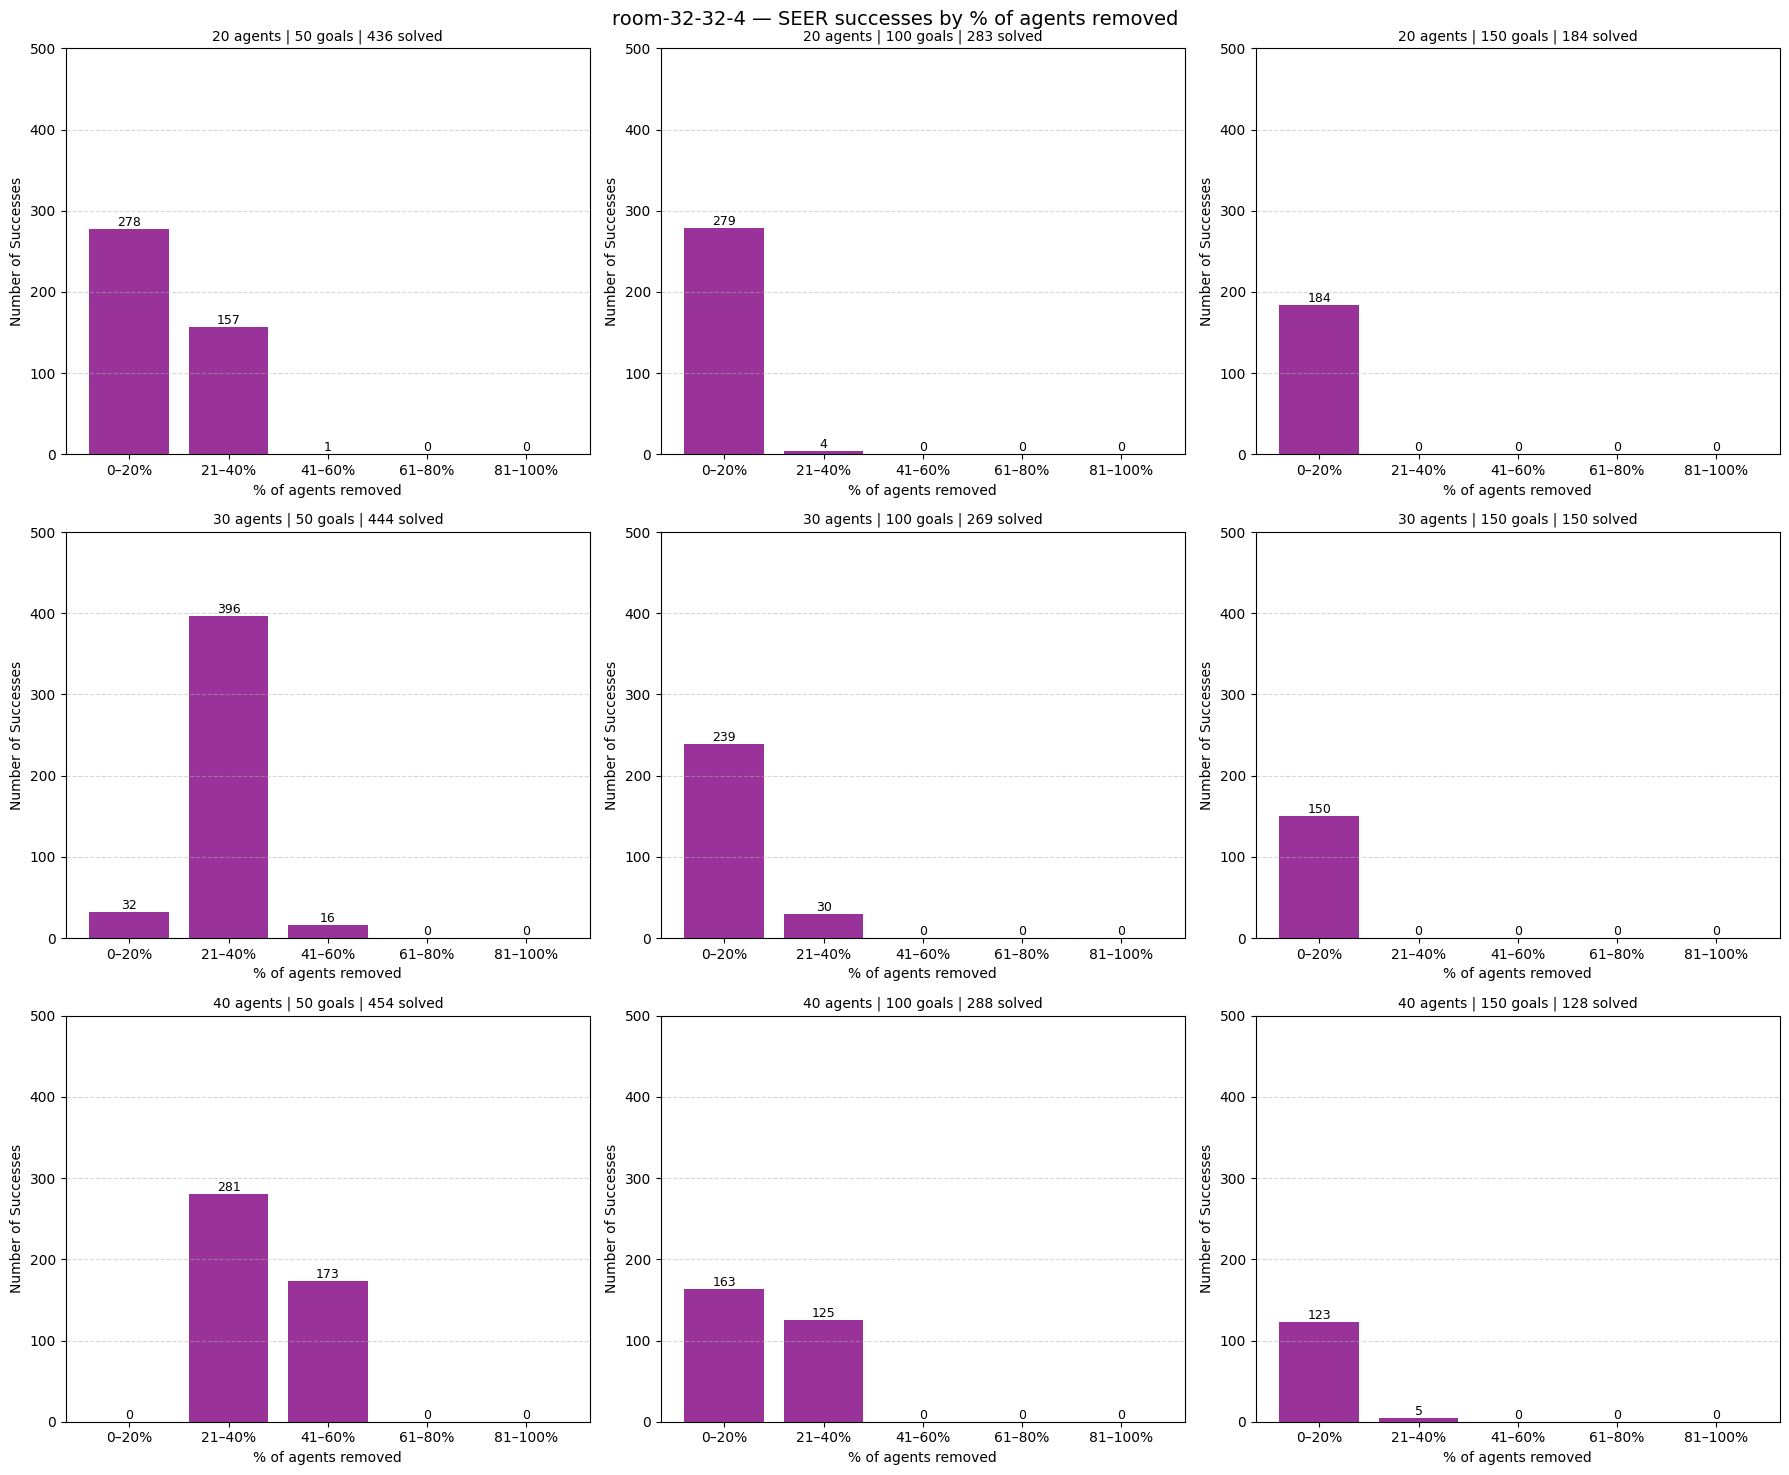

In [6]:
PCT_BINS   = [0, 20, 40, 60, 80, 100]
PCT_LABELS = ["0–20%", "21–40%", "41–60%", "61–80%", "81–100%"]

def plot_seer_by_pct(dmap, map_name):
    agent_vals, goal_vals, subs = grid_axes(dmap)
    nrows, ncols = len(agent_vals), len(goal_vals)

    sm_counts = {}
    for r in range(nrows):
        for c in range(ncols):
            sub = subs[(r, c)]
            sm = sub[sub["How To Remove"] == "SEER"].copy()
            if sm.empty:
                sm_counts[(r, c)] = None
                continue
            sm["pct_removed"] = sm["Number of removed agents"] / sm["Number of agents"] * 100
            sm["pct_bin"] = pd.cut(sm["pct_removed"], bins=PCT_BINS, labels=PCT_LABELS, include_lowest=True)
            counts = (sm[sm["success"]].groupby("pct_bin", observed=False)["Instance"].count()
                      .reindex(PCT_LABELS, fill_value=0))
            sm_counts[(r, c)] = (sm, counts)

    gmax = max((counts.max() for v in sm_counts.values() if v is not None for _, counts in [v]), default=1)
    y_max, yticks = _nice_axis(gmax)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{map_name} — SEER successes by % of agents removed", fontsize=14)
    for r, a in enumerate(agent_vals):
        for c, g in enumerate(goal_vals):
            ax = axes[r][c]
            v = sm_counts[(r, c)]
            if v is None:
                ax.set_title(f"{a} agents | {g} goals\n(no data)", fontsize=10)
                ax.axis("off")
                continue
            sm, counts = v
            bars = ax.bar(PCT_LABELS, counts.values, color=STRATEGY_STYLE["SEER"]["color"], alpha=0.8)
            ax.bar_label(bars, fontsize=9)
            ax.set_title(f"{a} agents | {g} goals | {sm['success'].sum()} solved", fontsize=10)
            ax.set_xlabel("% of agents removed", fontsize=10)
            ax.set_ylabel("Number of Successes", fontsize=10)
            ax.set_ylim(0, y_max)
            ax.set_yticks(yticks)
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_seer_by_pct(df_all[df_all["Map"] == m], m)

## Solved-Rate Comparison with Fixed-Size AESs

In [7]:
# DelayExclusion vs RandomExclusion vs SEER — solved % per map, broken down by removal level
# SEER isn't level-based (it picks its own removal count), so its solved% is one value per map,
# repeated on every level row for reference.
rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    seer_sub = dm[dm["How To Remove"] == "SEER"]
    seer_solved = seer_sub["success"].mean() * 100 if not seer_sub.empty else float("nan")

    excl = dm[dm["How To Remove"].isin(["DelayExclusion", "RandomExclusion"])].copy()
    excl["removal_level"] = excl.apply(_removal_level, axis=1)

    for lvl in LEVEL_ORDER:
        lvl_df = excl[excl["removal_level"] == lvl]
        de_sub = lvl_df[lvl_df["How To Remove"] == "DelayExclusion"]
        ra_sub = lvl_df[lvl_df["How To Remove"] == "RandomExclusion"]
        de_solved = de_sub["success"].mean() * 100 if not de_sub.empty else float("nan")
        ra_solved = ra_sub["success"].mean() * 100 if not ra_sub.empty else float("nan")
        rows.append({
            "Map": m, "Level": lvl,
            "DelayExclusion Solved%": f"{de_solved:.1f}%" if not pd.isna(de_solved) else "—",
            "RandomExclusion Solved%": f"{ra_solved:.1f}%" if not pd.isna(ra_solved) else "—",
            "SEER Solved%": f"{seer_solved:.1f}%" if not pd.isna(seer_solved) else "—",
        })
delay_vs_random = pd.DataFrame(rows)
delay_vs_random

,Map,Level,DelayExclusion Solved%,RandomExclusion Solved%,SEER Solved%
0,den520d,1,86.9%,86.8%,92.6%
1,den520d,20%,86.0%,87.6%,92.6%
2,den520d,40%,87.9%,88.8%,92.6%
3,den520d,60%,89.2%,91.4%,92.6%
4,den520d,80%,91.5%,93.7%,92.6%
5,den520d,N-1,100.0%,88.2%,92.6%
6,ht_chantry,1,65.0%,64.3%,77.2%
7,ht_chantry,20%,64.4%,63.8%,77.2%
8,ht_chantry,40%,62.7%,65.2%,77.2%
9,ht_chantry,60%,66.6%,68.4%,77.2%


## Online-SST Comparison at Selected Fixed Exclusion Sizes

In [8]:
# For each map, find the first removal level (in order 1, 20%, 40%, 60%, 80%, N-1) at which
# DelayExclusion / RandomExclusion first solves MORE than SEER — then compare avg Online SST
# only on the instances that both strategy AND SEER solved (co-solved), so it's an apples-to-apples cost comparison.
def first_level_beating_seer(dm, strategy, seer_solved_pct):
    excl = dm[dm["How To Remove"] == strategy].copy()
    excl["removal_level"] = excl.apply(_removal_level, axis=1)
    for lvl in LEVEL_ORDER:
        lvl_df = excl[excl["removal_level"] == lvl]
        if lvl_df.empty:
            continue
        if lvl_df["success"].mean() * 100 > seer_solved_pct:
            return lvl, lvl_df
    return None, None


rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    seer_df = dm[dm["How To Remove"] == "SEER"][MERGE_KEYS + ["success", "Online SST"]]
    seer_solved_pct = seer_df["success"].mean() * 100 if not seer_df.empty else float("nan")

    for strategy in ["DelayExclusion", "RandomExclusion"]:
        lvl, lvl_df = first_level_beating_seer(dm, strategy, seer_solved_pct)
        if lvl is None:
            rows.append({
                "Map": m, "Strategy": strategy, "First Level > SEER": "none",
                "Strategy Solved%": "—", "SEER Solved%": f"{seer_solved_pct:.1f}%",
                "Co-solved n": 0,
                "Strategy Avg SST (co-solved)": "—", "SEER Avg SST (co-solved)": "—",
            })
            continue

        strat_solved_pct = lvl_df["success"].mean() * 100
        merged = lvl_df[MERGE_KEYS + ["success", "Online SST"]].merge(
            seer_df, on=MERGE_KEYS, suffixes=("_strat", "_seer"))
        co = merged[merged["success_strat"] & merged["success_seer"]]
        strat_sst = co["Online SST_strat"].mean() if not co.empty else float("nan")
        seer_sst = co["Online SST_seer"].mean() if not co.empty else float("nan")

        rows.append({
            "Map": m, "Strategy": strategy, "First Level > SEER": lvl,
            "Strategy Solved%": f"{strat_solved_pct:.1f}%", "SEER Solved%": f"{seer_solved_pct:.1f}%",
            "Co-solved n": len(co),
            "Strategy Avg SST (co-solved)": f"{strat_sst:.1f}" if not pd.isna(strat_sst) else "—",
            "SEER Avg SST (co-solved)": f"{seer_sst:.1f}" if not pd.isna(seer_sst) else "—",
        })

delay_random_vs_seer_k = pd.DataFrame(rows)
delay_random_vs_seer_k

,Map,Strategy,First Level > SEER,Strategy Solved%,SEER Solved%,Co-solved n,Strategy Avg SST (co-solved),SEER Avg SST (co-solved)
0,den520d,DelayExclusion,N-1,100.0%,92.6%,4166,423887.9,15586.1
1,den520d,RandomExclusion,80%,93.7%,92.6%,3907,79608.3,15562.0
2,ht_chantry,DelayExclusion,80%,78.7%,77.2%,2767,14239.9,7913.6
3,ht_chantry,RandomExclusion,80%,78.0%,77.2%,2725,40379.2,7969.9
4,lak303d,DelayExclusion,N-1,100.0%,81.5%,3669,342312.0,11968.1
5,lak303d,RandomExclusion,80%,82.1%,81.5%,3007,61513.0,11889.2
6,maze-32-32-2,DelayExclusion,80%,73.9%,67.9%,2341,6301.9,3204.1
7,maze-32-32-2,RandomExclusion,N-1,100.0%,67.9%,3055,115562.7,3240.1
8,random-32-32-20,DelayExclusion,40%,84.7%,83.2%,3297,2727.5,2690.5
9,random-32-32-20,RandomExclusion,60%,86.3%,83.2%,3269,6932.7,2731.2
